In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

In [9]:
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv", encoding='utf-8-sig')
priority_df = pd.read_csv("../../data/processed/team/priority_area.csv", encoding='cp949')

In [12]:
# 호선명이 쉼표로 구분된 경우 행 분리(explode)
priority_exploded = priority_df.copy()
priority_exploded['호선명'] = (
    priority_exploded['호선명'].astype(str).str.split(',')
)
priority_exploded = priority_exploded.explode('호선명')
priority_exploded['호선명'] = priority_exploded['호선명'].str.strip()

# 호선별 역 수 집계
line_count = priority_exploded['호선명'].value_counts().sort_index()

In [13]:
# 전체 역도 동일하게 호선명 explode 처리
all_exploded = base_df.copy()
all_exploded['호선명'] = all_exploded['호선명'].astype(str).str.split(',')
all_exploded = all_exploded.explode('호선명')
all_exploded['호선명'] = all_exploded['호선명'].str.strip()

# 호선별 역 수 집계
all_line_count = all_exploded['호선명'].value_counts().sort_index()

# 가설 검증
무임승차 비중 상위 20%이며 시설 수준이 하위 20%인 역이라면, 개통 연차가 오래된 1~4호선 노선에 집중되어 있을 것이다.

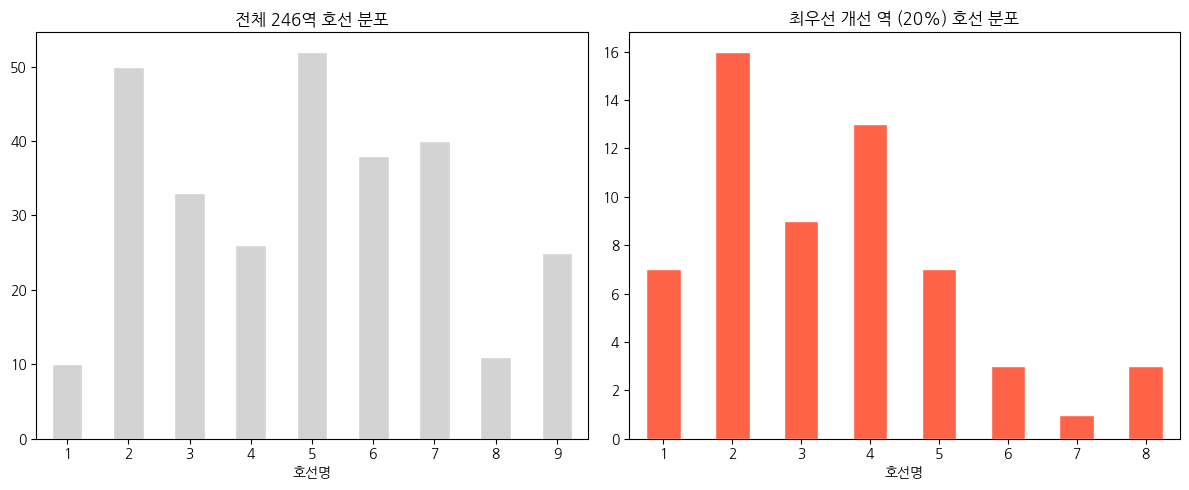

In [16]:
# 전체 vs 우선 개선 역 호선 분포 비교
cutoff_pct = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_line_count.plot(kind='bar', ax=axes[0], color='lightgray', edgecolor='white')
axes[0].set_title('전체 246역 호선 분포')
axes[0].tick_params(axis='x', rotation=0)

line_count.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title(f'최우선 개선 역 ({cutoff_pct}%) 호선 분포')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [21]:
# 가설: 시설부하지수 상위 20%이며 시설 수준이 하위 20%인 역은 개통 연차가 오래된 1~4호선에 집중되어 있을 것이다.
old_lines = ['1', '2', '3', '4']

old_ratio_all = all_exploded['호선명'].isin(old_lines).sum() / len(all_exploded) * 100
old_ratio_priority = priority_exploded['호선명'].isin(old_lines).sum() / len(priority_exploded) * 100

print(f"전체 역 중 1~4호선 비율: {old_ratio_all:.1f}%")
print(f"우선개선역 중 1~4호선 비율: {old_ratio_priority:.1f}%")
print(f"→ {'가설 지지 O' if old_ratio_priority > old_ratio_all else '가설 기각 X'}")

전체 역 중 1~4호선 비율: 41.8%
우선개선역 중 1~4호선 비율: 76.3%
→ 가설 지지 O


In [26]:
# 시설부하지수 하위 20% 필터링
low_threshold = base_df['시설부하지수'].quantile(0.20)

opposite = (
    base_df[base_df['시설부하지수'] <= low_threshold]
    .sort_values('시설부하지수', ascending=True)
    .copy()
)

print(f"해당 역 수: {len(opposite)}개")
print(opposite[['지하철역', '호선명', 'TOTAL', '무임승하차비중', '무임승하차', '시설부하지수']].to_string())

해당 역 수: 49개
       지하철역  호선명  TOTAL  무임승하차비중   무임승하차   시설부하지수
104      신길    5     15     9.14   26056   789.58
189     구반포    9     15    24.74   19600   816.67
219      동작  4,9     30    27.19   58272  1022.32
62      남태령    4      5    22.26   17097  1221.21
127    버티고개    6      9    24.34   31305  1304.38
120     녹사평    6     16    11.53   36739  1469.56
195      사평    9     22    22.12   50835  1495.15
191      노들    9     22    24.66   67097  1677.42
188    공항시장    9     21    28.34   51372  1712.40
30       용두    2     16    33.98   49798  1778.50
79       강일    5     24    27.49   89707  1868.90
196      샛강    9     17    16.69   61043  1907.59
199     신목동    9     14    21.14   50729  1951.12
200     신반포    9     18    23.42   58547  1951.57
130      상수    6     13     6.81   44855  2038.86
187      개화    9      6    18.72   24531  2044.25
231      오금  3,5     30    19.62  110883  2053.39
197     선유도    9     17    13.60   65336  2252.97
9       도림천    2      2    23.89   184

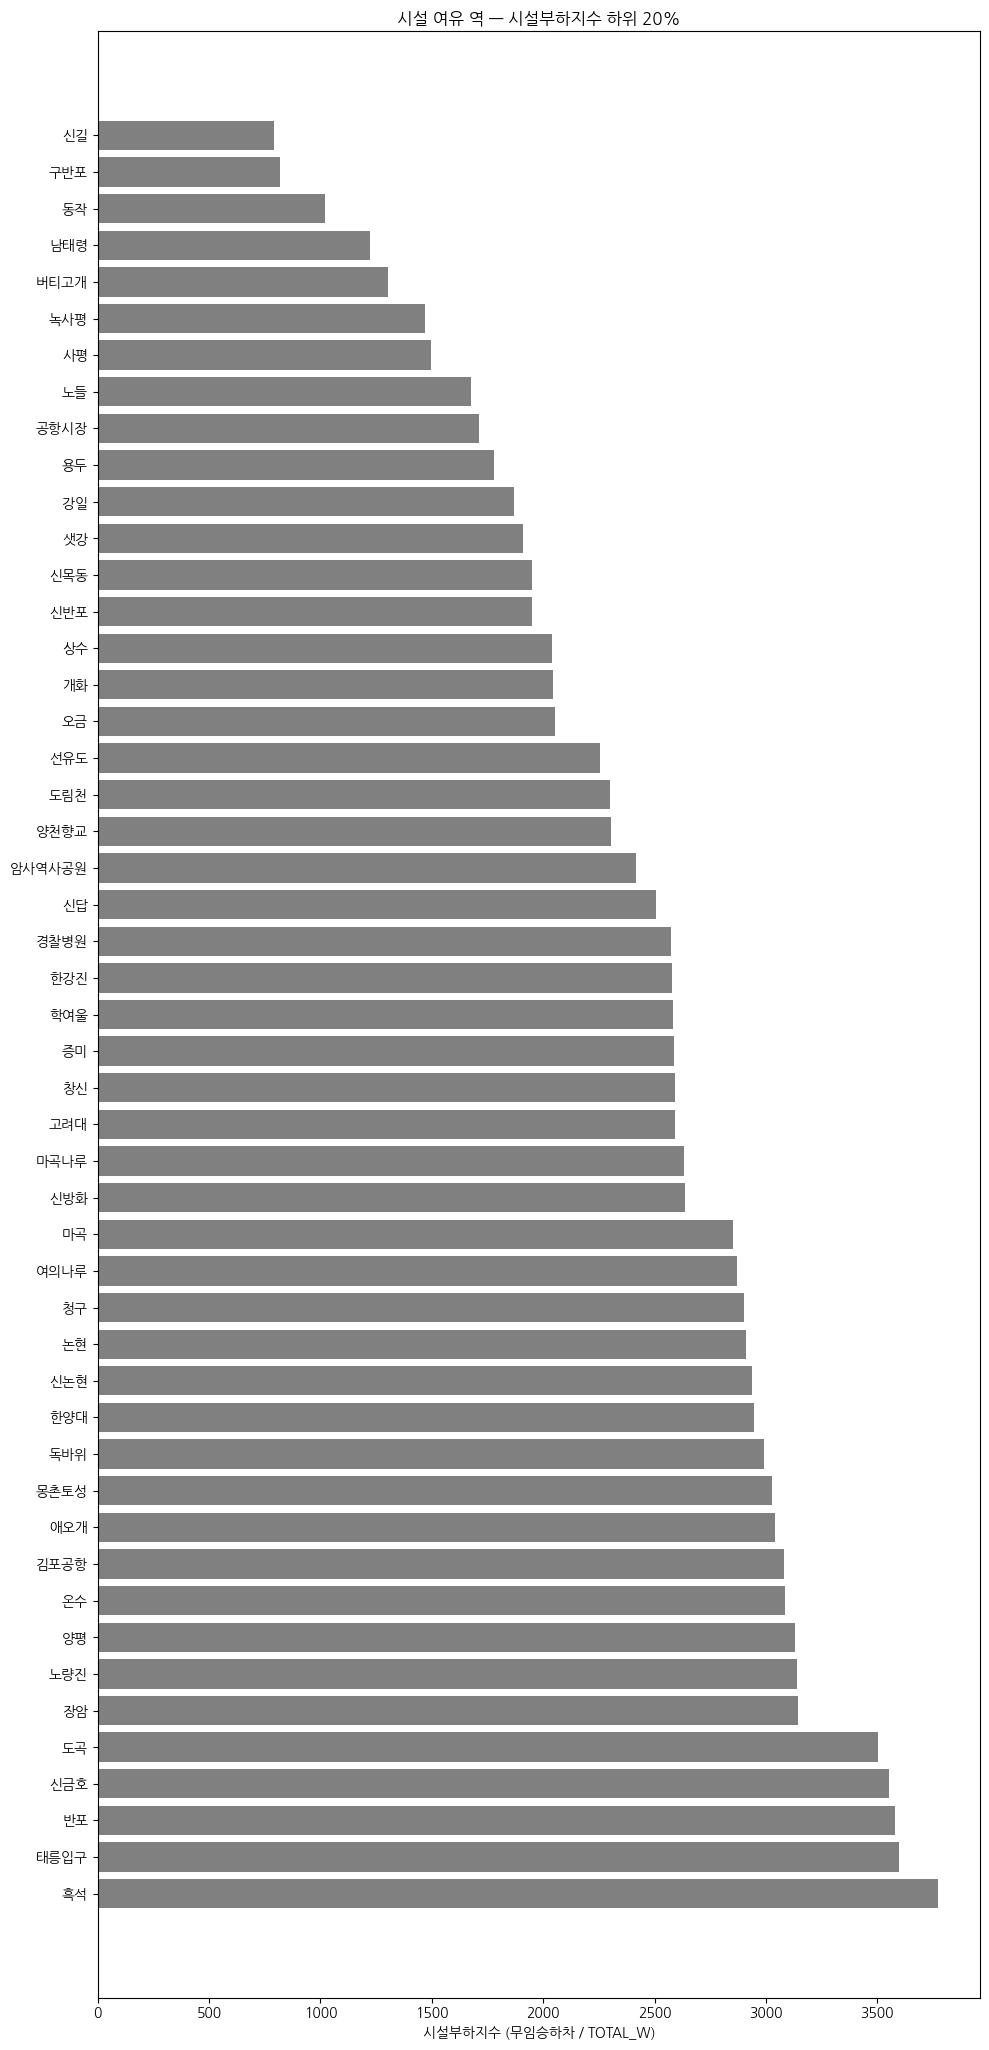

In [29]:
# 시설부하지수 하위 20% 시각화
fig, ax = plt.subplots(figsize=(10, len(opposite) * 0.4 + 1))

colors_opp = opposite['호선명'].map({
    1:'#0052A4', 2:'#00A84D', 3:'#EF7C1C', 4:'#00A5DE',
    5:'#996CAC', 6:'#CD7C2F', 7:'#747F00', 8:'#E6186C', 9:'#BDB092'
}).fillna('gray')

ax.barh(
    opposite['지하철역'],
    opposite['시설부하지수'],
    color=colors_opp
)
ax.set_xlabel('시설부하지수 (무임승하차 / TOTAL_W)')
ax.set_title('시설 여유 역 — 시설부하지수 하위 20%')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 분석 결론
우선개선역 중 1~4호선 비율은 76.3%, 전체 244개 역의 1~4호선 비율은 41.8%로 약 1,9배 높게 나타났다.

이는 구형 노선 